### DESAFIO

- O desafio de hoje é conseguir prever as vendas que vamos ter em determinado período com base nos gastos em anúncios <br> nas 3 grandes redes que a empresa da Hashtag investe: TV, rádio, Jornal

- Base de Dados: novos.csv | advertising.csv

- As vendas da base de dados advertising devem ser interpretadas como milhões

#### Passo a Passo de um Projeto de Ciência de Dados

- 1: Entendimento do Desafio

- 2: Entendimento da Área/Empresa

- 3: Extração de Dados

- 4: Tratamento/Limpeza de Dados

- 5: Análise Exploratória

- 6: Modelagem + Algoritmos

- 7: Interpretação dos resultados

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import sys
import os

sys.path.append(os.path.abspath('..'))


import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.ensemble import RandomForestRegressor
from functions.visualizacoes import plot_previsoes,plot_comparacao

In [21]:
sales_df = pd.read_csv(r'../data/advertising.csv')

In [22]:
display(sales_df)

,TV,Radio,Jornal,Vendas
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


### ANÁLISE EXPLORATÓRIA

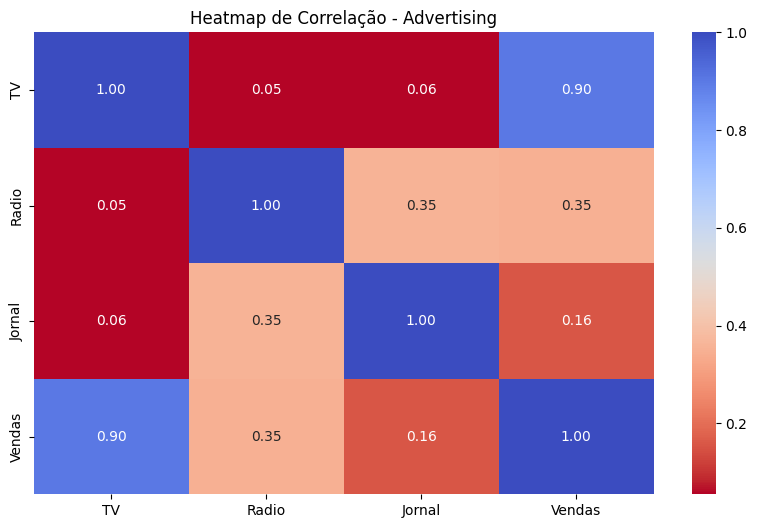

In [23]:
correlacao = sales_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlacao,
            annot=True,
            cmap='coolwarm_r',
            fmt='.2f')

plt.title('Heatmap de Correlação - Advertising')
plt.show()

Os investimentos em TV apresenta maior correlação com as vendas, seguido por Rádio com correlação mediana.<br> Jornal, apresenta baixo impacto, tendo menor contribuição para o aumento de vendas

### SEPARANDO DADOS DE TREINO E DADOS DE TESTE

- Y = Quem eu quero prever

- X = Todas as colunas que serão utilizadas pra descobrir Y

In [24]:
y = sales_df['Vendas']

x = sales_df.loc[:,sales_df.columns != 'Vendas']


X_treino, X_teste, y_treino, y_teste = train_test_split(x,
                                                        y,
                                                        test_size=0.3,
                                                        random_state=42)

In [25]:
print(X_treino.shape)
print(X_teste.shape)
print(y_treino.shape)
print(y_teste.shape)

(140, 3)
(60, 3)
(140,)
(60,)


## Escolha e Treinamento dos Modelos

Foram selecionados dois modelos de Machine Learning para este problema de regressão: **Regressão Linear** e **Random Forest**.

A **Regressão Linear** foi escolhida por ser um modelo simples, eficiente e altamente interpretável, servindo como um **baseline** para entender a relação entre os investimentos em mídia (TV, Rádio e Jornal) e as vendas.

O **Random Forest** foi utilizado por ser um modelo mais robusto, capaz de capturar **relações não lineares** e **interações complexas** entre as variáveis, podendo apresentar melhor desempenho preditivo em cenários mais complexos.

O treinamento de ambos os modelos permite uma comparação justa entre desempenho, erro médio e capacidade de generalização, possibilitando a escolha do modelo mais adequado para o problema proposto.

In [26]:
# MODELOS
modelo_linear = LinearRegression()
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# TREINO
modelo_linear.fit(X_treino, y_treino)
modelo_rf.fit(X_treino, y_treino)


# PREVISÕES
pred_linear = modelo_linear.predict(X_teste)
pred_rf = modelo_rf.predict(X_teste)


# AVALIAÇÃO
mae_linear = mean_absolute_error(y_teste, pred_linear)
r2_linear = r2_score(y_teste, pred_linear)

mae_rf = mean_absolute_error(y_teste, pred_rf)
r2_rf = r2_score(y_teste, pred_rf)


# RESULTADOS
resultados = pd.DataFrame({'Modelo': ['Linear Regression', 'Random Forest'],
                            'MAE': [round(mae_linear,2),round(mae_rf,2)],
                            'R²': [round(r2_linear,2),round(r2_rf,2)]})

display(resultados)


,Modelo,MAE,R²
0,Linear Regression,1.16,0.91
1,Random Forest,1.01,0.94


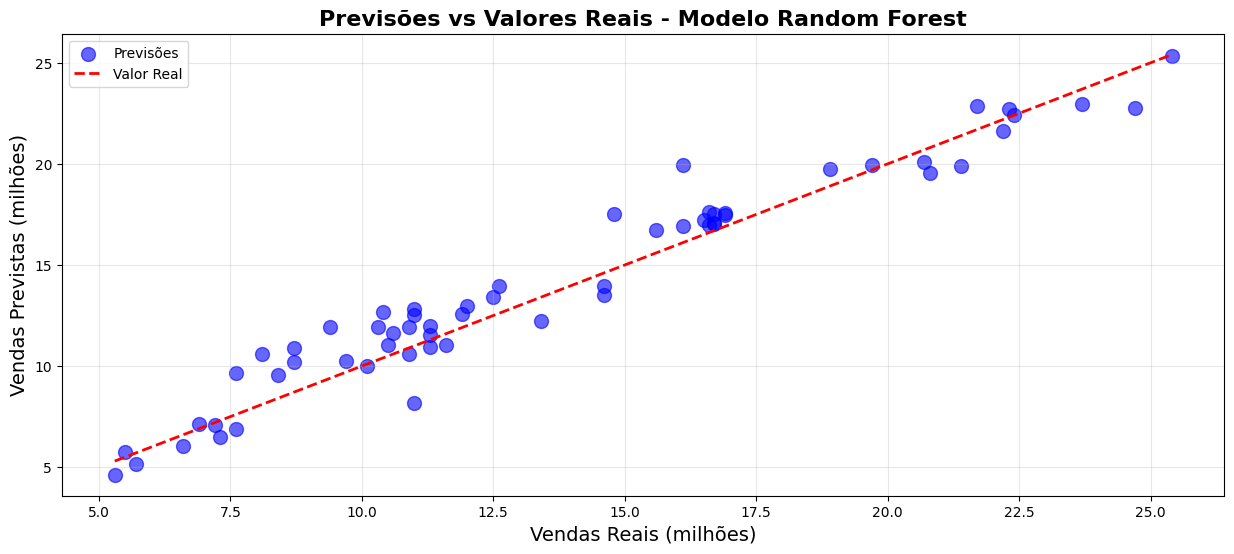

In [27]:
# Gráfico comparativo: Previsões vs Valores Reais
plot_previsoes(y_real=y_teste,
               y_pred=pred_rf,
               titulo='Previsões vs Valores Reais - Modelo Random Forest')

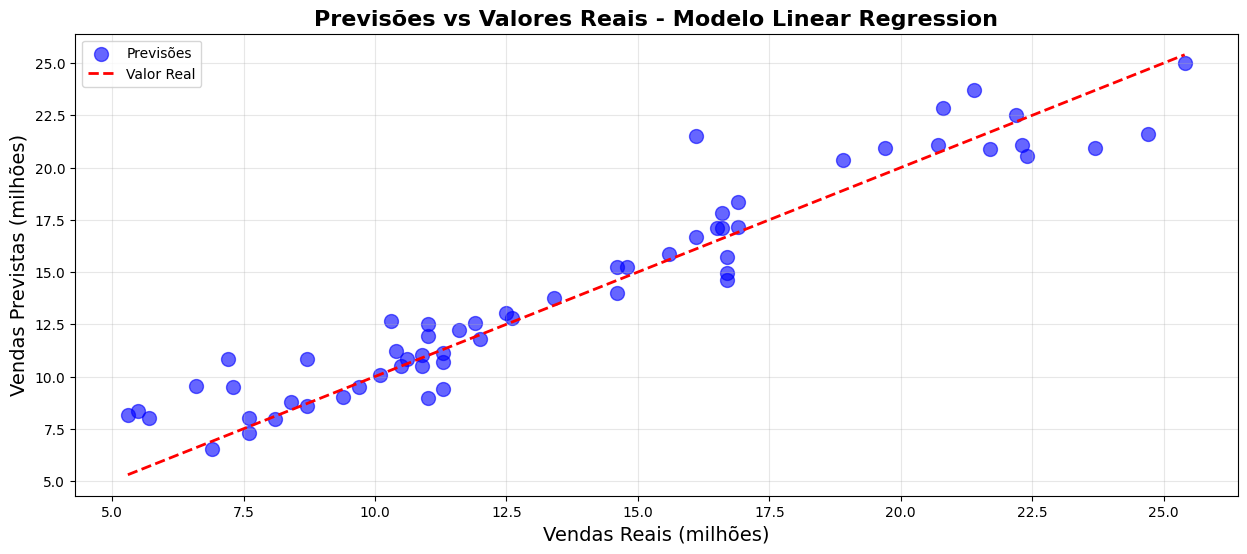

In [28]:
# Gráfico comparativo: Previsões vs Valores Reais
plot_previsoes(y_real=y_teste,
               y_pred=pred_linear,
               titulo='Previsões vs Valores Reais - Modelo Linear Regression')

- Pontos próximos da diagonal vermelha → previsões boas 

- Pontos muito afastados da diagonal vermelha → erro alto 

- Padrão em “nuvem” bem concentrada → modelo consistente

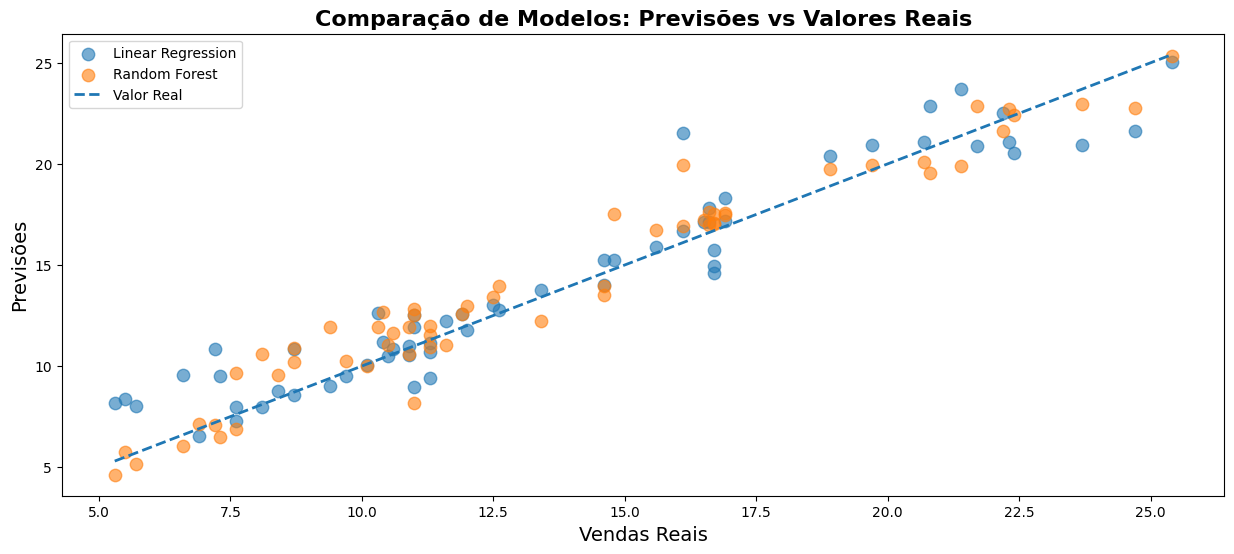

In [ ]:
plot_comparacao(y_real=y_teste,
                pred_1=pred_linear,
                pred_2=pred_rf,
                label_modelo1='Linear Regression',
                label_modelo2='Random Forest')

## Escolha do Modelo Final

Após o treinamento e avaliação dos modelos de Regressão Linear e Random Forest, o **Random Forest apresentou desempenho superior** em ambas as métricas avaliadas.

O modelo obteve um **R² maior**, indicando maior capacidade de explicação da variabilidade das vendas, além de um **MAE menor**, demonstrando menor erro médio nas previsões comparando à Regressão Linear.

Esse resultado sugere que as relações entre os investimentos em TV e as vendas não são estritamente lineares, sendo melhor capturadas por um modelo mais robusto e capaz de lidar com interações complexas entre as variáveis.

Dessa forma, o **Random Forest foi escolhido como modelo final** para previsão de vendas, apresentando melhor desempenho na previsão.

In [5]:
novos = pd.read_csv(r'../data/novos.csv')
display(novos)

,TV,Radio,Jornal
0,23.1,3.8,69.2
1,44.5,0.0,5.1
2,170.2,45.9,0.0
3,150.5,23.1,11.5


In [12]:
previsao = modelo_rf.predict(novos)

In [ ]:
print(f'{previsao}')

[ 7.726   9.919  20.2695]


## Previsão com Novos Dados

Com base nos novos investimentos em TV informados e utilizando o modelo **Random Forest**, foram realizadas previsões de vendas para o próximo período.

Os resultados indicam que o cenário com **maior investimento em TV** apresenta a **maior previsão de vendas**, ainda sendo o principal impulsionador de resultados.

De acordo com as previsões do modelo, **priorizar investimentos em TV** ainda é a estratégia mais eficiente para maximizar as vendas no próximo mês.